### 1. Imports and Libraries Preparation

In [1]:
# !pip install xgboost

In [81]:
# --- Data Preprocessing ---
import pandas as pd
import numpy as np

# --- Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning Modeling & Evaluation ---
from sklearn import datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import ( r2_score as r2, 
                        mean_absolute_error as mae, 
                        mean_squared_error as mse)

# --- Hyperparameter Tuning ---
from sklearn.model_selection import RandomizedSearchCV

# --- Model Saving ---
import joblib

### 2. Data Loading

- You can download dataset from kaggle like this [[house_prices_dataset](https://www.kaggle.com/datasets/muhamedumarjamil/house-price-prediction-dataset)]

- Or use sklearn.datasets if possible.

In [3]:
house_price_dataset = datasets.fetch_california_housing()

house_price_dataset

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [4]:
print(house_price_dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
house_price_df = pd.DataFrame(house_price_dataset.data, 
                    columns=house_price_dataset.feature_names)

house_price_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


- Add Price Target Column

In [6]:
house_price_df['Price'] = house_price_dataset.target

print(house_price_df.shape)

house_price_df.head(10)

(20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [7]:
house_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


- Save the Raw data

In [8]:
house_price_df.to_csv("../data/raw/house_prices_dataset.csv")

### 3. Data Cleaning & EDA
1. Handle Missing values.
2. Drop Duplicates.
3. Fix Wrong values and incorrect format.
4. Explore Correlations

In [9]:
house_price_df.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24,0.894


In [10]:
house_price_df.shape

(20640, 9)

In [11]:
house_price_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [12]:
house_price_df.isnull().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

In [13]:
house_price_df.duplicated().sum()

np.int64(0)

- Check Correlations

    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude


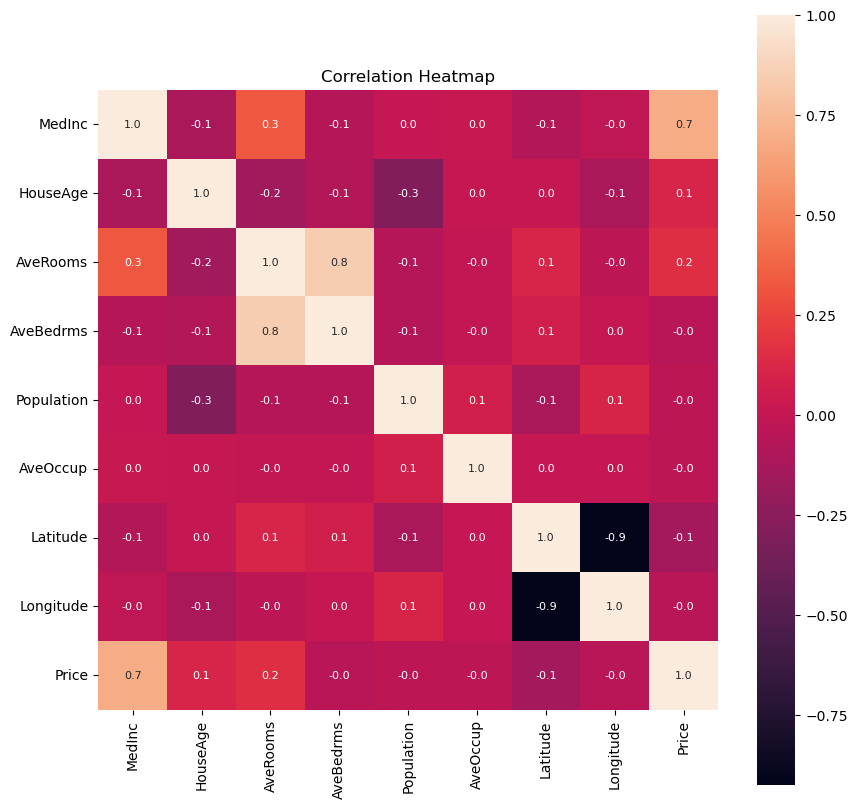

In [14]:
corr = house_price_df.corr()

plt.figure(figsize=(10, 10))
sns.heatmap(corr, cbar=True, square=True, fmt='.1f', annot=True, annot_kws={"size": 8})
plt.title("Correlation Heatmap")
plt.show()

- Histograms

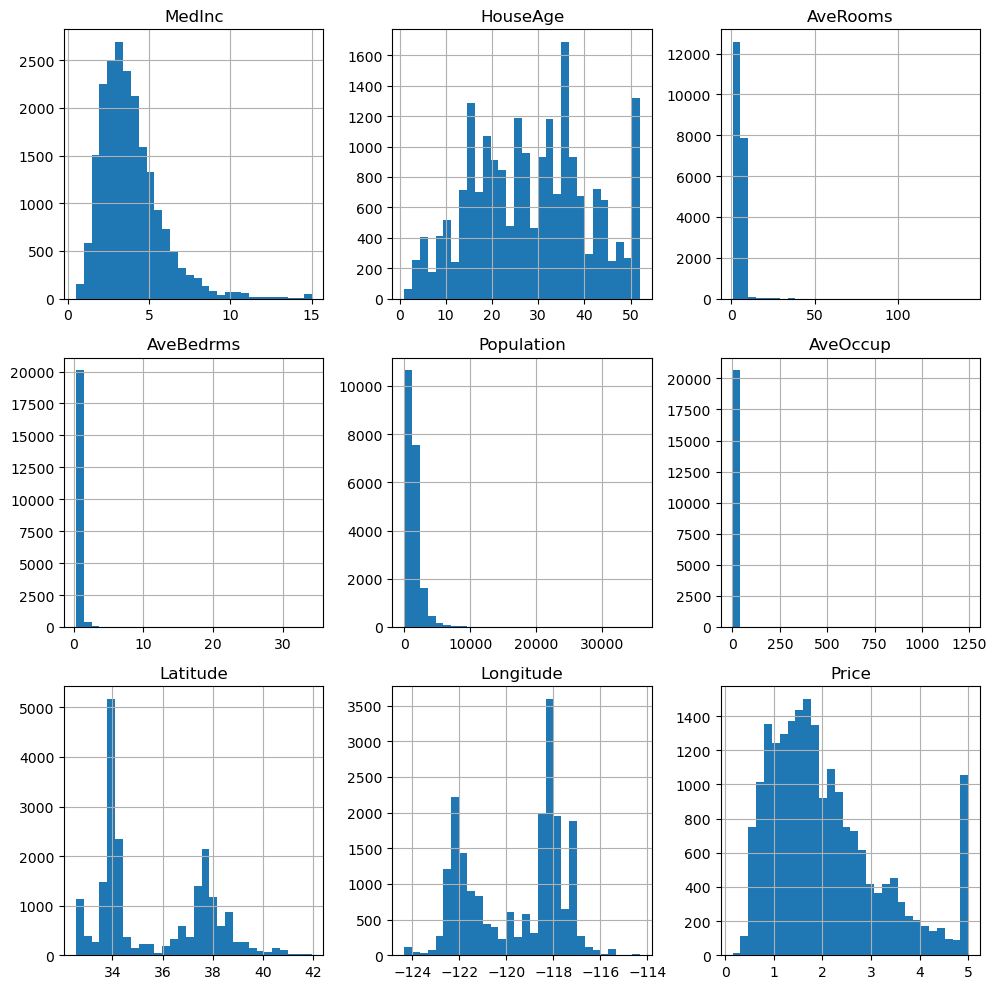

In [15]:
house_price_df.hist(figsize = (10, 10), bins = 30)
plt.tight_layout()
plt.show()

- Box Plots

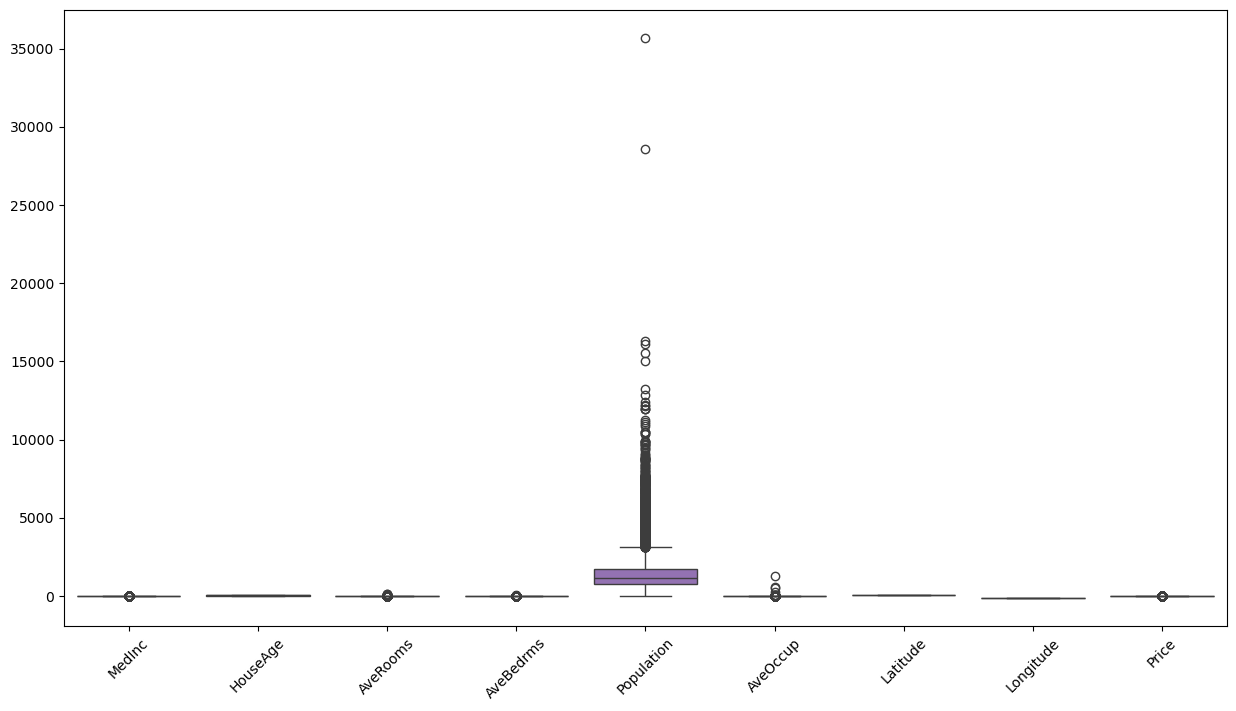

In [16]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=house_price_df)
plt.xticks(rotation = 45)
plt.show()

- Outlier Detection

1. Removing Outliers

In [17]:
# Remove Outliers
def remove_outliers(df):
    df_clean = df.copy()
    
    num_cols = df_clean.select_dtypes(include='number').columns
    
    Q1 = df_clean[num_cols].quantile(0.25)
    Q3 = df_clean[num_cols].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = ~( (df[num_cols] > upper_bound) |
                (df[num_cols] < lower_bound)).any(axis=1)

    # DataFrame without Outliers -> 
    # Keep parts that lower than or equal the upper bound 
    # and higher than or equal the lower bound
    return df_clean[mask]

In [18]:
df1 = remove_outliers(house_price_df)

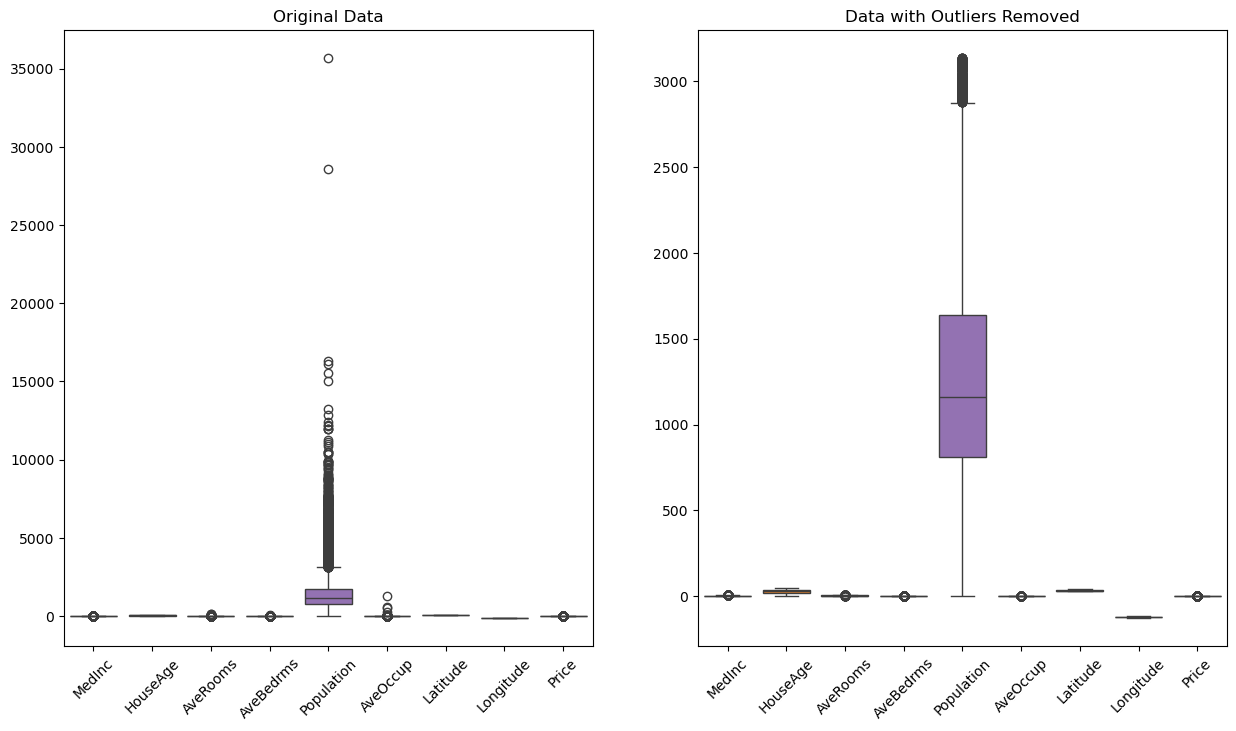

In [19]:
plt.figure(figsize=(15, 8))

# --- Original DataFrame ---
plt.subplot(1, 2, 1)
sns.boxplot(data=house_price_df)
plt.xticks(rotation=45)
plt.title("Original Data")

# --- DataFrame with Outliers Removed ---
plt.subplot(1, 2, 2)
sns.boxplot(data=df1)
plt.xticks(rotation=45)
plt.title("Data with Outliers Removed")

plt.show()

In [20]:
def cap_outliers(df):
    df_clean = df.copy()
    num_cols = df_clean.select_dtypes(include = 'number').columns
    Q1 = df_clean[num_cols].quantile(0.25)
    Q3 = df_clean[num_cols].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_clean[num_cols] = np.where(df_clean[num_cols] < lower_bound, lower_bound, df_clean[num_cols])
    df_clean[num_cols] = np.where(df_clean[num_cols] > upper_bound, upper_bound, df_clean[num_cols])

    return df_clean

In [21]:
df2 = cap_outliers(house_price_df)

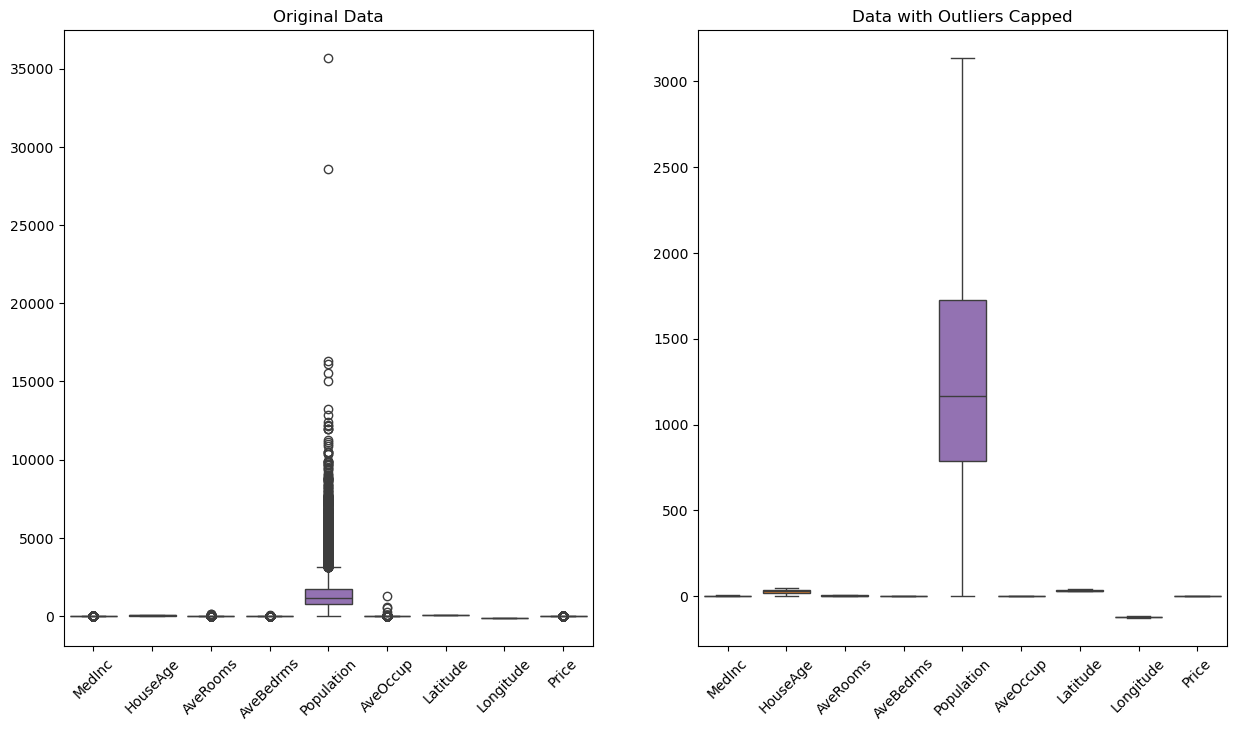

In [22]:
plt.figure(figsize=(15, 8))

# --- Original DataFrame ---
plt.subplot(1, 2, 1)
sns.boxplot(data=house_price_df)
plt.xticks(rotation=45)
plt.title("Original Data")

# --- DataFrame with Outliers Capped ---
plt.subplot(1, 2, 2)
sns.boxplot(data=df2)
plt.xticks(rotation=45)
plt.title("Data with Outliers Capped")

plt.show()

- Capping Outliers is the best choice here!

### 4. Split Data into Training and Testing

In [23]:
X = df2.drop(columns=["Price"])

y = df2['Price']

X.shape, y.shape

((20640, 8), (20640,))

In [24]:
X

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.013025,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.013025,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.257400,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.643100,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.846200,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.560300,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.556800,18.0,6.114035,1.239697,356.0,3.122807,39.49,-121.21
20637,1.700000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.867200,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [25]:
y

0        4.526
1        3.585
2        3.521
3        3.413
4        3.422
         ...  
20635    0.781
20636    0.771
20637    0.923
20638    0.847
20639    0.894
Name: Price, Length: 20640, dtype: float64

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((15480, 8), (5160, 8), (15480,), (5160,))

### 5. Machine Learning Modeling & Evaluation

In [39]:
model = XGBRegressor()

model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [46]:
# Training Operation
model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [47]:
# Testing Operation on Training Data
y_pred_train = model.predict(X_train)

y_pred_train

array([2.5204577, 1.2581913, 0.5937476, ..., 2.200662 , 4.767575 ,
       3.0162156], shape=(15480,), dtype=float32)

In [48]:
R2 = r2(y_train, y_pred_train)
MAE = mae(y_train, y_pred_train)
MSE = mse(y_train, y_pred_train)

print("--- Evaluation on Training Data ---")
print(f"R^2 Score = {R2:.3f}")
print(f"Mean Absolute Error = {MAE:.4f}")
print(f"Mean Squared Error = {MSE:.4f}")

--- Evaluation on Training Data ---
R^2 Score = 0.947
Mean Absolute Error = 0.1846
Mean Squared Error = 0.0675


In [49]:
# Testing Operation on Testing Data
y_pred = model.predict(X_test)

y_pred

array([3.074157 , 3.04052  , 2.9104617, ..., 2.077405 , 1.5768336,
       3.7372653], shape=(5160,), dtype=float32)

In [50]:
R2 = r2(y_test, y_pred)
MAE = mae(y_test, y_pred)
MSE = mse(y_test, y_pred)

print("--- Evaluation on Testing Data ---")
print(f"R^2 Score = {R2:.3f}")
print(f"Mean Absolute Error = {MAE:.4f}")
print(f"Mean Squared Error = {MSE:.4f}")

--- Evaluation on Testing Data ---
R^2 Score = 0.831
Mean Absolute Error = 0.3081
Mean Squared Error = 0.2176


### 6. Hyperparameter Tuning

In [52]:
param_dist = {
    "n_estimators": [300, 500, 700, 1000],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6],
    "subsample": [0.7, 0.8, 0.9, 1],
    "colsample_bytree": [0.7, 0.8, 0.9, 1],
    "reg_alpha": [0, 0.1, 0.5, 1],
    "reg_lambda": [0.5, 1, 2, 5]
}

In [53]:
random_search = RandomizedSearchCV(
    estimator= model,
    param_distributions= param_dist,
    n_iter= 50,
    scoring= 'r2',
    cv= 5,
    verbose= 1,
    n_jobs= -1,
    random_state= 42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'n_estimators': [300, 500, ...], ...}"
,n_iter,50
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [54]:
print(f"Best Parameters:\n{random_search.best_params_}")

print(f"Best CV Score: {random_search.best_score_}")

Best Parameters:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1}
Best CV Score: 0.849999565863232


### 7. Retraining Model using Best Params

In [72]:
best_model = XGBRegressor(
    subsample=0.8,
    reg_lambda=5,
    reg_alpha=1,
    n_estimators=700,
    max_depth=6,
    learning_rate=0.05,
    colsample_bytree=1,
    random_state=42
)

best_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [73]:
# Testing Operation on Training Data
y_pred_train = best_model.predict(X_train)

R2 = r2(y_train, y_pred_train)
MAE = mae(y_train, y_pred_train)
MSE = mse(y_train, y_pred_train)

print("--- Evaluation on Training Data ---")
print(f"R^2 Score = {R2:.3f}")
print(f"Mean Absolute Error = {MAE:.4f}")
print(f"Mean Squared Error = {MSE:.4f}")

--- Evaluation on Training Data ---
R^2 Score = 0.947
Mean Absolute Error = 0.1812
Mean Squared Error = 0.0681


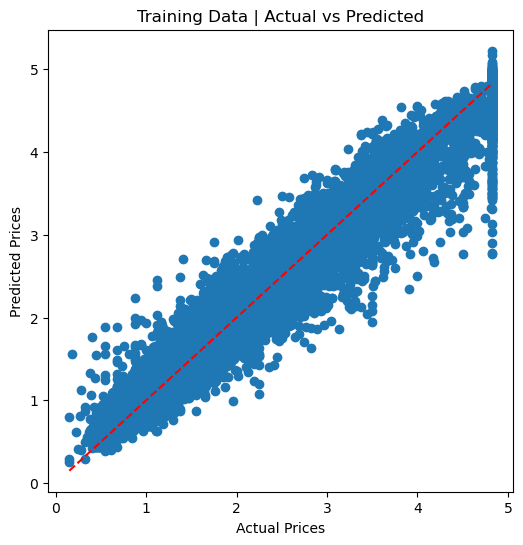

In [74]:
plt.figure(figsize=(6, 6))
plt.scatter(y_train, y_pred_train)

plt.plot([y_train.min(), y_train.max()],
        [y_train.min(), y_train.max()],
        'r--')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Training Data | Actual vs Predicted")
plt.show()

In [75]:
# Testing Operation on Testing Data
y_pred = best_model.predict(X_test)

R2 = r2(y_test, y_pred)
MAE = mae(y_test, y_pred)
MSE = mse(y_test, y_pred)

print("--- Evaluation on Testing Data ---")
print(f"R^2 Score = {R2:.3f}")
print(f"Mean Absolute Error = {MAE:.4f}")
print(f"Mean Squared Error = {MSE:.4f}")

--- Evaluation on Testing Data ---
R^2 Score = 0.849
Mean Absolute Error = 0.2884
Mean Squared Error = 0.1945


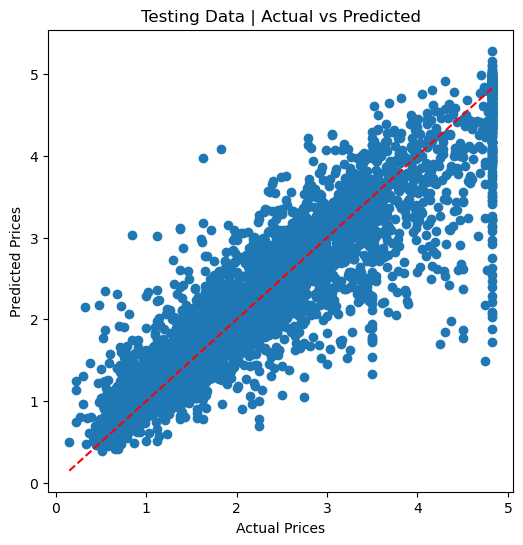

In [76]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Testing Data | Actual vs Predicted")
plt.show()

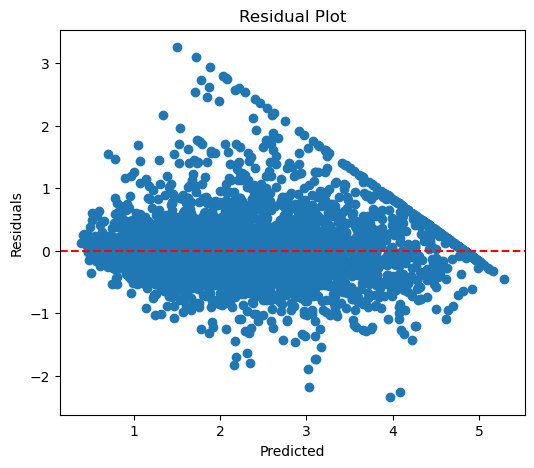

In [77]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

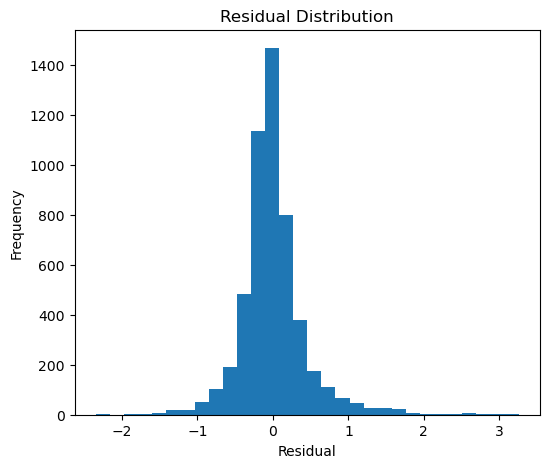

In [78]:
plt.figure(figsize=(6, 5))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

In [79]:
print("Train R2:", best_model.score(X_train, y_train))
print("Test R2 :", best_model.score(X_test, y_test))

Train R2: 0.9468049100756503
Test R2 : 0.848602454012895


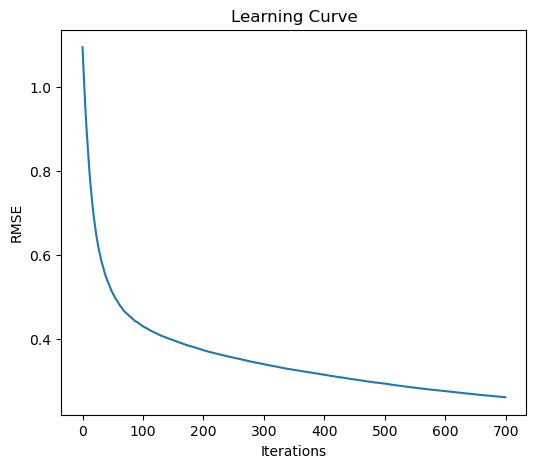

In [80]:
results = best_model.evals_result()

plt.figure(figsize=(6, 5))
plt.plot(results['validation_0']['rmse'])
plt.title("Learning Curve")
plt.xlabel("Iterations")
plt.ylabel("RMSE")
plt.show()

### 8. Model Saving
- Save Model to disk so it can be used later without retraining and for Deployment

In [82]:
# Save model to disk
joblib.dump(best_model, '../models/xgb_house_price_model.pkl')

['../models/xgb_house_price_model.pkl']

In [83]:
# Load model later
loaded_model = joblib.load("../models/xgb_house_price_model.pkl")

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


In [84]:
# Test prediction
y_pred = loaded_model.predict(X_test)

In [85]:
y_pred

array([2.7708535, 2.9224381, 2.9871316, ..., 2.0875742, 1.5309155,
       3.6750002], shape=(5160,), dtype=float32)

#### XGBoost Native Method

In [87]:
best_model.save_model('../models/xgb_house_price_model.json')

In [88]:
loaded_model = XGBRegressor()
loaded_model.load_model("../models/xgb_house_price_model.json")

# Test
y_pred = loaded_model.predict(X_test)

In [89]:
y_pred

array([2.7708535, 2.9224381, 2.9871316, ..., 2.0875742, 1.5309155,
       3.6750002], shape=(5160,), dtype=float32)

### Predictive System

In [90]:
sample = np.array([[8.3252, 41.0, 6.98, 1.02, 322.0, 2.55, 37.88, -122.23]])

prediction = model.predict(sample)

print(f"Predicted House Price: ${prediction[0]*100_000:,.0f}")

Predicted House Price: $430,359
